In [19]:
# VALIDATION NOTE (linked to manuscript):
# This cell generates audited semantic and geometric sample tables for Supplementary Note 4
# in SI.tex (Tables S3/S4 workflow), supporting Technical Validation in main.tex.

# generate_audit_samples
import pandas as pd
import os
import sys
import importlib
import hashlib
from pathlib import Path

# Ensure config is refreshed
try:
    import config
    importlib.reload(config)
    from config import (
        RULE_ENGINE_OUTPUT_PATH,        # Step 3
        LLM_VERIFICATION_OUTPUT,        # Step 4
        AI_DECISIONS_LOG_PATH,          # Step 6 (Raw AI Reasoning)
        FINAL_SUGGESTIONS_PATH,         # Step 7 (Arbitration Logic)
        VERIFICATION_DIR
    )
    # Step 5: Merged Result (Absolute Final)
    ABSOLUTE_FINAL_CSV = RULE_ENGINE_OUTPUT_PATH.replace('RuleEngine_Final.csv', 'Absolute_Final.csv')
    # Step 7 Result: Final Calibrated Result
    AI_CALIBRATED_CSV = RULE_ENGINE_OUTPUT_PATH.replace('RuleEngine_Final.csv', 'AI_Calibrated.csv')
except ImportError as e:
    print(f"[ERROR] Failed to import config: {e}")
    raise




# Public reproducible mode (default): write to VERIFICATION_DIR with fixed random seed.
def clean_id(x):
    """Normalize IDs to string and remove decimal points."""
    if pd.isna(x): return ""
    return str(x).split('.')[0].strip()

def main():
    print("[INFO] Generating multi-stage audit samples for SI...")
    out_dir = VERIFICATION_DIR
    os.makedirs(out_dir, exist_ok=True)

    # =========================================================================
    # 1. LLM Section: Rule(S3) vs LLM(S4) vs Final(S5)
    # =========================================================================
    if all(os.path.exists(f) for f in [RULE_ENGINE_OUTPUT_PATH, LLM_VERIFICATION_OUTPUT, ABSOLUTE_FINAL_CSV]):
        print("\n-> Building LLM Decision Chain (S3 -> S4 -> S5)...")
        df3 = pd.read_csv(RULE_ENGINE_OUTPUT_PATH, low_memory=False)
        df4 = pd.read_csv(LLM_VERIFICATION_OUTPUT, low_memory=False)
        df5 = pd.read_csv(ABSOLUTE_FINAL_CSV, low_memory=False)

        for df in [df3, df4, df5]:
            df['BUILDINGSTRUCTUREID'] = df['BUILDINGSTRUCTUREID'].apply(clean_id)
        
        df3 = df3.set_index('BUILDINGSTRUCTUREID')
        df4 = df4.set_index('BUILDINGSTRUCTUREID')
        df5 = df5.set_index('BUILDINGSTRUCTUREID')

        # Sample targets (High confidence LLM corrections)
        llm_ids = df4[df4['LLM_Confidence'] >= 0.8].index

        sample_ids = None

        if sample_ids is None:
            llm_ids_sorted = sorted(
                list(llm_ids),
                key=lambda x: hashlib.sha256(str(x).encode('utf-8')).hexdigest()
            )
            sample_ids = pd.Index(llm_ids_sorted[:min(100, len(llm_ids_sorted))])

        audit_llm = pd.DataFrame(index=sample_ids)
        audit_llm['Building_Name'] = df5.loc[sample_ids, 'BUILDINGNAMEEN']
        audit_llm['Matched_POIs'] = df5.loc[sample_ids, 'Matched_POIs']
        
        # --- Step 3: Rule Baseline (With Reasoning) ---
        audit_llm['S3_Rule_Main'] = df3.loc[sample_ids, 'Final_Main_Class']
        audit_llm['S3_Rule_Sub'] = df3.loc[sample_ids, 'Final_Sub_Class']
        audit_llm['S3_Rule_Props'] = df3.loc[sample_ids, 'Sub_Class_Proportions']
        audit_llm['S3_Rule_Reasoning'] = df3.loc[sample_ids, 'Evidence_Details'] # 👈 Added Rule reasoning

        # --- Step 4: LLM Inference ---
        audit_llm['S4_LLM_Main'] = df4.loc[sample_ids, 'LLM_Main_Class']
        audit_llm['S4_LLM_Sub'] = df4.loc[sample_ids, 'LLM_Sub_Class']
        audit_llm['S4_LLM_Reasoning'] = df4.loc[sample_ids, 'LLM_Reasoning']

        # --- Step 5: Final Result ---
        audit_llm['S5_Final_Main'] = df5.loc[sample_ids, 'Final_Main_Class']
        audit_llm['S5_Final_Sub'] = df5.loc[sample_ids, 'Final_Sub_Class']
        audit_llm['S5_Final_Props'] = df5.loc[sample_ids, 'Sub_Class_Proportions']
        audit_llm['S5_Final_Source'] = df5.loc[sample_ids, 'Classification_Source']
        
        # --- Ground Truth Columns ---
        audit_llm['GT_S3_Correct(1/0)'] = ""
        audit_llm['GT_S4_Correct(1/0)'] = ""
        audit_llm['GT_S5_Correct(1/0)'] = ""

        path_llm = os.path.join(out_dir, "Audit_LLM_System_Gain_SI.csv")
        audit_llm.to_csv(path_llm, encoding='utf-8-sig')
        print(f"[INFO] LLM SI audit table generated: {path_llm}")

    # =========================================================================
    # 2. Vision Section: Raw AI(S6) vs Calibration Logic(S7)
    # =========================================================================
    if all(os.path.exists(f) for f in [AI_DECISIONS_LOG_PATH, FINAL_SUGGESTIONS_PATH, AI_CALIBRATED_CSV]):
        print("\n-> Building Vision Decision Chain (S6 -> S7)...")
        df_raw_ai = pd.read_csv(AI_DECISIONS_LOG_PATH, low_memory=False) 
        df_sugg = pd.read_csv(FINAL_SUGGESTIONS_PATH, low_memory=False)
        df7 = pd.read_csv(AI_CALIBRATED_CSV, low_memory=False)

        # Normalize IDs
        for d in [df_raw_ai, df_sugg]:
            d['fragment_id'] = d['fragment_id'].apply(clean_id)
            d['host_id'] = d['host_id'].apply(clean_id)
        df7['BUILDINGSTRUCTUREID'] = df7['BUILDINGSTRUCTUREID'].apply(clean_id)
        df7 = df7.set_index('BUILDINGSTRUCTUREID')

        # Sample Merge/Delete actions
        candidate_vis = df_sugg[df_sugg['final_suggestion'].str.contains('merge|delete', case=False, na=False)].copy()

        vision_samples = None

        if vision_samples is None:
            candidate_vis['_pair_key_'] = candidate_vis['fragment_id'].astype(str) + '||' + candidate_vis['host_id'].astype(str)
            candidate_vis['_hash_'] = candidate_vis['_pair_key_'].apply(lambda s: hashlib.sha256(s.encode('utf-8')).hexdigest())
            vision_samples = candidate_vis.sort_values('_hash_').head(min(100, len(candidate_vis))).drop(columns=['_hash_'])
        
        # 🚨 FIX: Resolve naming conflict by merging with explicit suffixes
        merged_vision = pd.merge(
            vision_samples, 
            df_raw_ai[['fragment_id', 'host_id', 'ai_decision', 'ai_reasoning']], 
            on=['fragment_id', 'host_id'], 
            how='left', 
            suffixes=('_sugg', '_raw')
        )
        
        audit_vis = pd.DataFrame()
        audit_vis['Fragment_ID'] = merged_vision['fragment_id']
        audit_vis['Host_ID'] = merged_vision['host_id']
        
        # --- Step 6: Raw AI Perception ---
        audit_vis['S6_AI_Decision'] = merged_vision['ai_decision_raw'] # 👈 Fixed the KeyError
        audit_vis['S6_AI_Reasoning'] = merged_vision['ai_reasoning_raw']
        
        # --- Step 7: Calibration Arbitration ---
        audit_vis['S7_Final_Applied_Action'] = merged_vision['final_suggestion']
        audit_vis['S7_Calibration_Reasoning'] = merged_vision['suggestion'] # 👈 Added the 'Why' for calibration logic
        audit_vis['S7_Final_Source'] = audit_vis['Fragment_ID'].map(lambda x: df7.loc[x, 'Classification_Source'] if x in df7.index else 'Unknown')
        
        # --- Ground Truth Columns ---
        audit_vis['GT_S6_AI_Correct(1/0)'] = ""
        audit_vis['GT_S7_Applied_Correct(1/0)'] = ""

        path_vis = os.path.join(out_dir, "Audit_Vision_System_Gain_SI.csv")
        audit_vis.to_csv(path_vis, index=False, encoding='utf-8-sig')
        print(f"[INFO] Vision SI audit table generated: {path_vis}")

    print("[INFO] SI audit files are ready. Check Validation_Materials.")

if __name__ == "__main__":

    main()


[INFO] Generating multi-stage audit samples for SI...

-> Building LLM Decision Chain (S3 -> S4 -> S5)...
[INFO] LLM SI audit table generated: d:\HKBFETD\intermediate_files\validation_materials\Audit_LLM_System_Gain_SI.csv

-> Building Vision Decision Chain (S6 -> S7)...
[INFO] Vision SI audit table generated: d:\HKBFETD\intermediate_files\validation_materials\Audit_Vision_System_Gain_SI.csv
[INFO] SI audit files are ready. Check Validation_Materials.


In [16]:
# VALIDATION NOTE (linked to manuscript):
# This cell extracts audited VLM image pairs for SI visual evidence (Fig. S1 style examples)
# referenced in Supplementary Note 4 and geometric audit descriptions in main.tex.

# extract_vision_audit_images
import os
import sys
import shutil
import pandas as pd
import importlib
from tqdm.auto import tqdm

current_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)
src_dir = os.path.join(current_dir, 'src')
if os.path.exists(src_dir) and src_dir not in sys.path:
    sys.path.insert(0, src_dir)

try:
    import config
    importlib.reload(config)
    from config import VERIFICATION_DIR, INTERMEDIATE_DIR, IMAGE_OUTPUT_DIR
    
    CSV_PATH = os.path.join(VERIFICATION_DIR, "Audit_Vision_System_Gain_SI.csv")
    VISION_CHECK_DIR = os.path.join(VERIFICATION_DIR, "Vision_Check")
    if not IMAGE_OUTPUT_DIR:
        IMAGE_OUTPUT_DIR = os.path.join(INTERMEDIATE_DIR, "geometry_correction_candidates")
        
except ImportError as e:
    raise

def clean_id(x):
    if pd.isna(x): return ""
    return str(x).split('.')[0].strip()

def main():
    
    if not os.path.exists(CSV_PATH):
        return

    os.makedirs(VISION_CHECK_DIR, exist_ok=True)

    df = pd.read_csv(CSV_PATH, low_memory=False)
    
    if 'Fragment_ID' not in df.columns or 'Host_ID' not in df.columns:
        return

    success_count = 0
    missing_images = []

    for index, row in tqdm(df.iterrows(), total=len(df), desc="coping images"):
        frag_id = clean_id(row['Fragment_ID'])
        host_id = clean_id(row['Host_ID'])
        
        if not frag_id or not host_id:
            continue

        plain_img_name = f"{frag_id}_vs_{host_id}_plain.png"
        overlay_img_name = f"{frag_id}_vs_{host_id}_overlay.png"

        source_plain = os.path.join(IMAGE_OUTPUT_DIR, plain_img_name)
        source_overlay = os.path.join(IMAGE_OUTPUT_DIR, overlay_img_name)

        target_plain = os.path.join(VISION_CHECK_DIR, plain_img_name)
        target_overlay = os.path.join(VISION_CHECK_DIR, overlay_img_name)

        if os.path.exists(source_plain):
            shutil.copy2(source_plain, target_plain)
            success_count += 1
        else:
            missing_images.append(plain_img_name)

        if os.path.exists(source_overlay):
            shutil.copy2(source_overlay, target_overlay)
            success_count += 1
        else:
            missing_images.append(overlay_img_name)

    print("\n[INFO] Vision audit image extraction finished.")
    print(f"[INFO] Copied images: {success_count}")
    print(f"[INFO] Missing images: {len(missing_images)}")
    
    if missing_images:
        for img in missing_images[:5]:
            print(f"   - {img}")
        if len(missing_images) > 5:
            print(f"   ... and {len(missing_images)-5} more")

if __name__ == "__main__":

    main()


coping images:   0%|          | 0/100 [00:00<?, ?it/s]


[INFO] Vision audit image extraction finished.
[INFO] Copied images: 198
[INFO] Missing images: 2
   - 246202_vs_148549_plain.png
   - 246202_vs_148549_overlay.png


In [17]:
# VALIDATION NOTE (linked to manuscript):
# This cell computes OZP zoning-alignment diagnostics used to support the
# "Zoning Alignment Ratio" analysis discussed in Technical Validation (main.tex).

# ozp_alignment

import pandas as pd
import os

def calculate_ozp_alignment():
    from pathlib import Path
    cwd = Path.cwd()
    candidates = [
        cwd / "output" / "HK_UBEM_Buildings_Public_v1.csv",
        cwd.parent / "output" / "HK_UBEM_Buildings_Public_v1.csv",
    ]
    dataset_path = None
    for c in candidates:
        if c.exists():
            dataset_path = str(c)
            break
    if dataset_path is None:
        dataset_path = str(candidates[0])
    
    if not os.path.exists(dataset_path):
        print(f"[ERROR] Dataset not found: {dataset_path}")
        return

    df = pd.read_csv(dataset_path)
    
    df['Calculated_GFA'] = df['Footprint_Area_sqm_占地面积'] * df['Floors_Count_地上层数']

    records = []
    # Use canonical English sub-class token for robust manuscript statistics.
    mapping_dict = {
        "Public Housing": "Residential",
        "Private Housing": "Residential",
        "HA Subsidized Sale Flats": "Residential",
        "Other Housing": "Residential",
        "Office": "Commercial",
        "Retail": "Commercial",
        "Restaurant": "Commercial",
        "Accommodation": "Commercial",
        "Human Health": "Commercial",
        "Education": "Commercial",
        "Data Centre": "Commercial",
        "Other Commercial": "Commercial"
    }

    def normalize_category_label(label):
        text = str(label).strip()
        if not text or text.lower() == 'nan':
            return ''
        if '_' in text:
            return text.split('_', 1)[0].strip()
        if '（' in text and '）' in text:
            left = text.find('（')
            right = text.rfind('）')
            english_part = text[left + 1:right].strip()
            if english_part:
                return english_part
        return text


    for _, row in df.iterrows():
        total_gfa = row['Calculated_GFA']
        if pd.isna(total_gfa) or total_gfa == 0:
            continue
            
        ozp_code = str(row['OZP_Zone_Code_法定图则代码']).strip().upper()
        prop_str = str(row['UBEM_Mixed_Proportions_混合比例'])

        def add_record(cat, gfa):
            sector = mapping_dict.get(normalize_category_label(cat))
            if sector:
                records.append({'Sector': sector, 'OZP': ozp_code, 'GFA': gfa})

        if pd.isna(prop_str) or prop_str == 'nan' or prop_str.strip() == '':
            add_record(str(row['UBEM_Sub_Class_子类别']), total_gfa)
        else:
            parts = prop_str.split('-')
            for p in parts:
                if ':' in p:
                    cat, ratio_str = p.rsplit(':', 1)
                    try:
                        ratio = float(ratio_str)
                    except:
                        ratio = 1.0
                    add_record(cat, total_gfa * ratio)
                else:
                    add_record(p, total_gfa)

    df_records = pd.DataFrame(records)

    def is_com_compatible(ozp):
        if pd.isna(ozp): return False
        if ozp == 'C' or ozp.startswith('C ') or ozp.startswith('C('): return True
        if ozp.startswith('C/R'): return True
        if ozp.startswith('CDA'): return True
        return False

    def is_res_compatible(ozp):
        if pd.isna(ozp): return False
        if ozp.startswith('R(A)') or ozp.startswith('R(B)') or ozp.startswith('R(C)') or ozp.startswith('R(D)') or ozp.startswith('R(E)'): return True
        if ozp == 'V' or ozp.startswith('V ') or ozp.startswith('V('): return True
        if ozp.startswith('C/R'): return True
        if ozp.startswith('CDA'): return True
        return False

    df_com = df_records[df_records['Sector'] == 'Commercial']
    com_total = df_com['GFA'].sum()
    com_matched = df_com[df_com['OZP'].apply(is_com_compatible)]['GFA'].sum()
    com_ratio = (com_matched / com_total) * 100 if com_total > 0 else 0

    df_res = df_records[df_records['Sector'] == 'Residential']
    res_total = df_res['GFA'].sum()
    res_matched = df_res[df_res['OZP'].apply(is_res_compatible)]['GFA'].sum()
    res_ratio = (res_matched / res_total) * 100 if res_total > 0 else 0

    print(f"[INFO] Commercial zoning alignment: {com_ratio:.2f}%")
    print(f"[INFO] Residential zoning alignment: {res_ratio:.2f}%")
    return {"commercial_alignment_pct": com_ratio, "residential_alignment_pct": res_ratio}

if __name__ == "__main__":
    calculate_ozp_alignment()


[INFO] Commercial zoning alignment: 8.09%
[INFO] Residential zoning alignment: 45.94%


Saved tower list: d:\HKBFETD\output\validation_plots\podium_212166_towers.csv


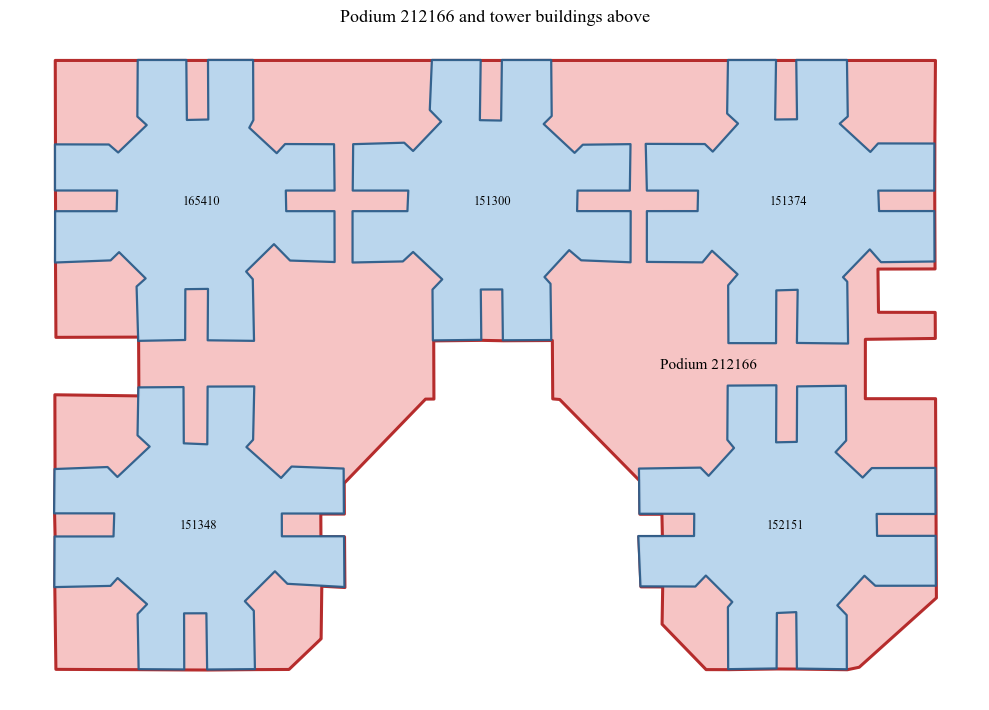

Saved figure: d:\HKBFETD\output\validation_plots\podium_212166_with_towers_rotated.png


In [18]:
# VALIDATION NOTE (linked to manuscript):
# This cell creates case-level validation plots for podium-tower geometry context
# corresponding to the real-world case verification narrative in Technical Validation.

import os
import math
import re
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.affinity import rotate
from shapely.geometry import Polygon, MultiPolygon

# =========================
# =========================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'

# =========================
# =========================
from pathlib import Path
cwd = Path.cwd()
_geo_candidates = [
    cwd / "output" / "HK_UBEM_Buildings_Public_v1.geojson",
    cwd.parent / "output" / "HK_UBEM_Buildings_Public_v1.geojson",
]
GEOJSON_PATH = str(next((x for x in _geo_candidates if x.exists()), _geo_candidates[0]))
OUT_DIR = str((Path(GEOJSON_PATH).parent / "validation_plots"))
os.makedirs(OUT_DIR, exist_ok=True)

ID_COL = "Building_ID_建筑ID"
STRUCT_COL = "LandsD_Structure_Type_地政署建筑类型"
MAIN_COL = "UBEM_Main_Class_主类别"
SUB_COL = "UBEM_Sub_Class_子类别"
NAME_EN_COL = "LandsD_Building_Name_EN_地政署英文名"
NAME_TC_COL = "LandsD_Building_Name_TC_地政署中文名"
POI_COL = "Crowdsourced_POIs_Matched_众包POI匹配详情"

TARGET_PODIUM_ID = 212166

FALLBACK_BUFFER_M = 8

MANUAL_ROTATION_OFFSET_DEG = 180

gdf = gpd.read_file(GEOJSON_PATH)

if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:2326", allow_override=True)

gdf[ID_COL] = gdf[ID_COL].astype(str)

def get_by_id(gdf, bid):
    out = gdf[gdf[ID_COL] == str(bid)].copy()
    if out.empty:
        raise ValueError(f"找不到 Building ID = {bid}")
    return out

def safe_str(x):
    if x is None:
        return ""
    s = str(x)
    if s.lower() in ["nan", "none", "null"]:
        return ""
    return s.strip()

def extract_block_numbers_from_poi(poi_text):
    poi_text = safe_str(poi_text)
    nums = set()

    patterns = [
        r"Block\s*(\d+)",
        r"第\s*(\d+)\s*座"
    ]
    for pat in patterns:
        for m in re.findall(pat, poi_text, flags=re.IGNORECASE):
            try:
                nums.add(int(m))
            except:
                pass
    return nums

def row_contains_block_number(row, block_num):
    text = " ".join([
        safe_str(row.get(NAME_EN_COL, "")),
        safe_str(row.get(NAME_TC_COL, "")),
        safe_str(row.get(POI_COL, ""))
    ])
    patterns = [
        rf"\bBlock\s*{block_num}\b",
        rf"第\s*{block_num}\s*座"
    ]
    return any(re.search(p, text, flags=re.IGNORECASE) for p in patterns)

def find_towers_on_podium(gdf, podium_row, fallback_buffer_m=8):
    podium_geom = podium_row.geometry
    podium_poi = safe_str(podium_row.get(POI_COL, ""))

    towers = gdf[gdf[STRUCT_COL] == "T"].copy()
    towers = towers[towers.geometry.notna() & ~towers.geometry.is_empty].copy()

    inside_mask = towers.geometry.representative_point().within(podium_geom)
    towers_inside = towers[inside_mask].copy()

    if towers_inside.empty:
        near_mask = towers.geometry.intersects(podium_geom.buffer(fallback_buffer_m))
        towers_inside = towers[near_mask].copy()

    block_nums = extract_block_numbers_from_poi(podium_poi)
    if block_nums:
        towers_block = towers_inside[
            towers_inside.apply(
                lambda r: any(row_contains_block_number(r, b) for b in block_nums),
                axis=1
            )
        ].copy()

        if not towers_block.empty:
            return towers_block

    return towers_inside

def longest_edge_angle_deg(geom):
    mrr = geom.minimum_rotated_rectangle
    coords = list(mrr.exterior.coords)

    max_len = -1
    best_angle = 0.0

    for i in range(len(coords) - 1):
        x1, y1 = coords[i]
        x2, y2 = coords[i + 1]
        dx = x2 - x1
        dy = y2 - y1
        seg_len = math.hypot(dx, dy)
        if seg_len > max_len:
            max_len = seg_len
            best_angle = math.degrees(math.atan2(dy, dx))

    return best_angle

def rotate_gdf(gdf_in, angle_deg, origin_geom):
    origin = origin_geom.centroid
    gdf_out = gdf_in.copy()
    gdf_out["geometry"] = gdf_out["geometry"].apply(
        lambda geom: rotate(geom, angle=angle_deg, origin=(origin.x, origin.y))
    )
    return gdf_out

def plot_podium_towers_rotated(podium_gdf, towers_gdf, out_png):
    podium_row = podium_gdf.iloc[0]
    podium_geom = podium_row.geometry

    angle = longest_edge_angle_deg(podium_geom)
    rotate_by = -angle + MANUAL_ROTATION_OFFSET_DEG

    podium_rot = rotate_gdf(podium_gdf, rotate_by, podium_geom)
    towers_rot = rotate_gdf(towers_gdf, rotate_by, podium_geom) if not towers_gdf.empty else towers_gdf

    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    podium_rot.plot(
        ax=ax,
        facecolor="#f6c1c1",
        edgecolor="#b22222",
        linewidth=2.2,
        alpha=0.95
    )

    if not towers_rot.empty:
        towers_rot.plot(
            ax=ax,
            facecolor="#b7d8f0",
            edgecolor="#2c5d8a",
            linewidth=1.6,
            alpha=0.95
        )

    p_pt = podium_rot.iloc[0].geometry.representative_point()
    ax.text(
        p_pt.x, p_pt.y,
        f"Podium {int(podium_rot.iloc[0][ID_COL])}",
        fontsize=11, ha="center", va="center", color="black"
    )

    for _, row in towers_rot.iterrows():
        pt = row.geometry.representative_point()
        ax.text(
            pt.x, pt.y,
            f"{int(row[ID_COL])}",
            fontsize=9, ha="center", va="center", color="black"
        )

    ax.set_title(f"Podium {TARGET_PODIUM_ID} and tower buildings above", fontsize=13)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    return rotate_by

podium = get_by_id(gdf, TARGET_PODIUM_ID)
podium_row = podium.iloc[0]

towers = find_towers_on_podium(gdf, podium_row, fallback_buffer_m=FALLBACK_BUFFER_M)

check_cols = [
    ID_COL, STRUCT_COL, MAIN_COL, SUB_COL,
    NAME_EN_COL, NAME_TC_COL, POI_COL
]
out_csv = os.path.join(OUT_DIR, f"podium_{TARGET_PODIUM_ID}_towers.csv")
towers[check_cols].to_csv(out_csv, index=False, encoding="utf-8-sig")
print(f"Saved tower list: {out_csv}")

out_png = os.path.join(OUT_DIR, f"podium_{TARGET_PODIUM_ID}_with_towers_rotated.png")
rot_deg = plot_podium_towers_rotated(podium, towers, out_png)
print(f"Saved figure: {out_png}")
